In [1]:
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer , PorterStemmer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("bbc_news_text_complexity_summarization.csv")
nltk.download("punk")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("punkt_tab")
nltk.download("punkt")


[nltk_data] Error loading punk: Package 'punk' not found in index
[nltk_data] Downloading package stopwords to /home/asher/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/asher/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/asher/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/asher/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /home/asher/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
df.head()

,text,labels,no_sentences,Flesch Reading Ease Score,Dale-Chall Readability Score,text_rank_summary,lsa_summary
0,Ad sales boost Time Warner profit\n\nQuarterly...,business,26,62.17,9.72,It hopes to increase subscribers by offering t...,Its profits were buoyed by one-off gains which...
1,Dollar gains on Greenspan speech\n\nThe dollar...,business,17,65.56,9.09,The dollar has hit its highest level against t...,"""I think the chairman's taking a much more san..."
2,Yukos unit buyer faces loan claim\n\nThe owner...,business,14,69.21,9.66,The owners of embattled Russian oil giant Yuko...,Yukos' owner Menatep Group says it will ask Ro...
3,High fuel prices hit BA's profits\n\nBritish A...,business,24,62.98,9.86,Looking ahead to its full year results to Marc...,"Rod Eddington, BA's chief executive, said the ..."
4,Pernod takeover talk lifts Domecq\n\nShares in...,business,17,70.63,10.23,Reports in the Wall Street Journal and the Fin...,Shares in UK drinks and food firm Allied Domec...


In [4]:
stop_words = set(stopwords.words('english'))
print('stop_words')
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

stop_words


In [11]:
def process_text(text):
  word_tokens = word_tokenize(text)
  filtered_tokens = [word for word in word_tokens if word.lower() not in stop_words]
  lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]

  return{
      "Orginal_Text": text,
      "Word_Tokens": word_tokens,
      "Filtered_Tokens": filtered_tokens,
      "Lemmatized_Tokens": lemmatized_tokens,
    }

In [8]:
results = df["text"].apply(process_text)


processed_df = pd.DataFrame(results.tolist())

print(processed_df.head())

processed_file_path = "processed_nlp_dataset.csv"
processed_df.to_csv(processed_file_path, index=False)

print(f"Processed data saved to {processed_file_path}")

                                        Orginal_Text  \
0  Ad sales boost Time Warner profit\n\nQuarterly...   
1  Dollar gains on Greenspan speech\n\nThe dollar...   
2  Yukos unit buyer faces loan claim\n\nThe owner...   
3  High fuel prices hit BA's profits\n\nBritish A...   
4  Pernod takeover talk lifts Domecq\n\nShares in...   

                                         Word_Tokens  \
0  [Ad, sales, boost, Time, Warner, profit, Quart...   
1  [Dollar, gains, on, Greenspan, speech, The, do...   
2  [Yukos, unit, buyer, faces, loan, claim, The, ...   
3  [High, fuel, prices, hit, BA, 's, profits, Bri...   
4  [Pernod, takeover, talk, lifts, Domecq, Shares...   

                                     Filtered_Tokens  \
0  [Ad, sales, boost, Time, Warner, profit, Quart...   
1  [Dollar, gains, Greenspan, speech, dollar, hit...   
2  [Yukos, unit, buyer, faces, loan, claim, owner...   
3  [High, fuel, prices, hit, BA, 's, profits, Bri...   
4  [Pernod, takeover, talk, lifts, Domecq, Sha

In [12]:
from sklearn.feature_extraction.text import CountVectorizer
text_data = df
vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(text_data)
bow_df = pd.DataFrame(bow_matrix.toarray(),columns=vectorizer.get_feature_names_out())
print("Bag of words Representation:")
print(bow_df)

Bag of words Representation:
   chall  dale  ease  flesch  labels  lsa_summary  no_sentences  readability  \
0      0     0     0       0       0            0             0            0   
1      0     0     0       0       1            0             0            0   
2      0     0     0       0       0            0             1            0   
3      0     0     1       1       0            0             0            0   
4      1     1     0       0       0            0             0            1   
5      0     0     0       0       0            0             0            0   
6      0     0     0       0       0            1             0            0   

   reading  score  text  text_rank_summary  
0        0      0     1                  0  
1        0      0     0                  0  
2        0      0     0                  0  
3        1      1     0                  0  
4        0      1     0                  0  
5        0      0     0                  1  
6        0     

In [13]:
bow_df.to_csv("bag_of_words.csv", index=False)
print("\nBag of words saved as 'bag_of_words.csv',")


Bag of words saved as 'bag_of_words.csv',


In [14]:
def lemmatize_text(Text):
    tokens = word_tokenize(str(Text))
    return ' '.join([lemmatizer.lemmatize(word) for word in tokens])
def stem_text(Text):
    tokens = word_tokenize(str(Text))
    return ' '.join([stemmer.stem(word) for word in tokens])


In [20]:
df['lemmatized_text'] = df['text'].apply(lemmatize_text)
df['stemed_text'] = df['text'].apply(stem_text)

In [21]:
output_path = 'lemmatization vs stemming.csv'
df.to_csv(output_path,index=False)

In [22]:
df

,text,labels,no_sentences,Flesch Reading Ease Score,Dale-Chall Readability Score,text_rank_summary,lsa_summary,lemmatized_text,stemed_text
0,Ad sales boost Time Warner profit\n\nQuarterly...,business,26,62.17,9.72,It hopes to increase subscribers by offering t...,Its profits were buoyed by one-off gains which...,Ad sale boost Time Warner profit Quarterly pro...,ad sale boost time warner profit quarterli pro...
1,Dollar gains on Greenspan speech\n\nThe dollar...,business,17,65.56,9.09,The dollar has hit its highest level against t...,"""I think the chairman's taking a much more san...",Dollar gain on Greenspan speech The dollar ha ...,dollar gain on greenspan speech the dollar ha ...
2,Yukos unit buyer faces loan claim\n\nThe owner...,business,14,69.21,9.66,The owners of embattled Russian oil giant Yuko...,Yukos' owner Menatep Group says it will ask Ro...,Yukos unit buyer face loan claim The owner of ...,yuko unit buyer face loan claim the owner of e...
3,High fuel prices hit BA's profits\n\nBritish A...,business,24,62.98,9.86,Looking ahead to its full year results to Marc...,"Rod Eddington, BA's chief executive, said the ...",High fuel price hit BA 's profit British Airwa...,high fuel price hit ba 's profit british airwa...
4,Pernod takeover talk lifts Domecq\n\nShares in...,business,17,70.63,10.23,Reports in the Wall Street Journal and the Fin...,Shares in UK drinks and food firm Allied Domec...,Pernod takeover talk lift Domecq Shares in UK ...,pernod takeov talk lift domecq share in uk dri...
...,...,...,...,...,...,...,...,...,...
2122,New consoles promise big problems\n\nMaking ga...,tech,52,60.85,9.20,Instead of employing lots of artists to create...,Mr Wright said that enabling players to devise...,New console promise big problem Making game fo...,new consol promis big problem make game for fu...
2123,BT program to beat dialler scams\n\nBT is intr...,tech,17,56.29,9.23,If a bill rises substantially above its usual ...,BT is introducing two initiatives to help beat...,BT program to beat dialler scam BT is introduc...,bt program to beat dialler scam bt is introduc...
2124,Be careful how you code\n\nA new European dire...,tech,45,56.29,8.73,"If it gets its way, the Dutch government will ...",A new European directive could put software wr...,Be careful how you code A new European directi...,be care how you code a new european direct cou...
2125,US cyber security chief resigns\n\nThe man mak...,tech,16,47.42,9.14,Amit Yoran was director of the National Cyber ...,The man making sure US computer networks are s...,US cyber security chief resigns The man making...,us cyber secur chief resign the man make sure ...


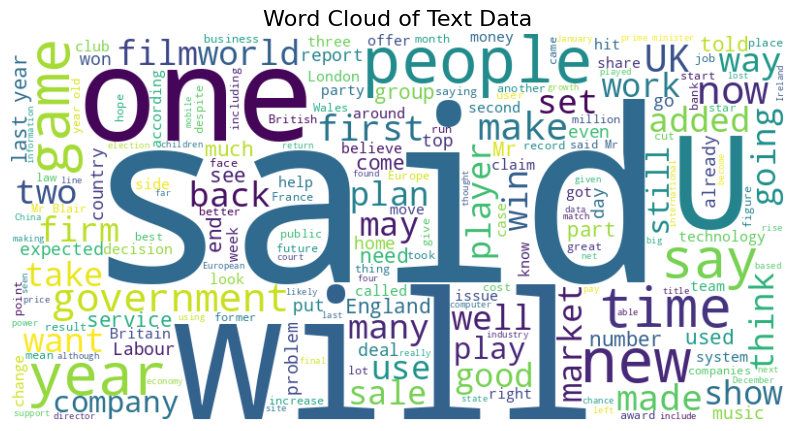

In [24]:
text_data = " ".join(df['text'].dropna())
wordcloud = WordCloud(width=800 , height=400 , background_color="white").generate(text_data)
plt.figure(figsize=(10,9))
plt.imshow(wordcloud,interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Text Data",fontsize=16)
plt.show()

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df)
print(vectorizer.get_feature_names_out())

['chall' 'dale' 'ease' 'flesch' 'labels' 'lemmatized_text' 'lsa_summary'
 'no_sentences' 'readability' 'reading' 'score' 'stemed_text' 'text'
 'text_rank_summary']


In [26]:
print(X.toarray())

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  1.         0.        ]
 [0.         0.         0.         0.         1.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         1.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.51893807 0.51893807 0.         0.
  0.         0.         0.         0.51893807 0.43830336 0.
  0.         0.        ]
 [0.51893807 0.51893807 0.         0.         0.         0.
  0.         0.         0.51893807 0.         0.43830336 0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         1.        ]
 [0.         0.         0.         0.         0.         0.
  1.         0.         0.         0.         0.         0.
  0.      